# FigGamma1 residuals — net ground-state photoionization, $(n_1\Gamma_{\rm Ly}-\alpha_1n_en_p)/\alpha_An_en_p$, vs radius

Companion to FigGamma1.ipynb, same inputs and loader. $\Gamma_{\rm Ly}$ is the simulated ground-state photoionization
rate built from the per-cell Monte-Carlo field, and $\alpha_1(T_e)\,n_en_p$ is the rate the on-the-spot recombination
continuum alone would balance. The plotted quantity is the excess of ground-state photoionization over direct-to-ground
recombination, normalised to the **total** recombination rate $\alpha_A(T_e)\,n_en_p$ — the same normalisation as
FigGamma2_residuals and FigGamma3_residuals, so the three levels' net rates are in one currency.

The **Case B** reference (dashed) is the classical nebular balance: the direct-to-ground recombination continuum is
reabsorbed on the spot ($\alpha_1n_en_p$) and the transmitted Lyman continuum balances the rest,
$n_1\Gamma^\star_{\rm Ly}=\alpha_Bn_en_p$, so $n_1\Gamma_{\rm Ly}=\alpha_An_en_p$ and the normalised residual is
$\alpha_B/\alpha_A$, drawn at each cell's $T_e$ (0.62 at $10^4$ K, 0.53 at $4\times10^4$ K). Zero is the decoupled
regime beyond the Lyman transition, where $n=1$ sees only its own recombination photons and the Balmer band carries
the ionization balance (the counterpart of the Case B level in FigGamma2_residuals); there the residual sits at the
percent level. No Sirocco rate estimators are used; both quantities come from the spectral output, the level
populations and $T_e$.

Vertical markers use the definitions and colours shared with FigOpticalDepth and FigHeatCool: the Lyman radius (blue) is where the inside-out Lyman-continuum absorption depth from the base reaches
$\tau_{\rm LyC}=3$ (`breaks.lyc_transition_radius`; the incident LyC is then attenuated by $e^{-3}$ and ground-state
ionization has handed over to the on-the-spot recombination continuum), and the scattering surface (goldenrod) is where
the outward electron-scattering column from the converged edge reaches $\tau_{\rm es}=1$. The recombination front (red) is
where the hydrogen neutral fraction first reaches $x_{\rm HI}=0.5$ (inside the converged domain only for m5, m10 and m15;
m2.5 stays more than half ionized throughout). All three residual figures
share the $\alpha_An_en_p$ normalisation and the same linear y-range, so their amplitudes can be compared directly.


In [1]:
import os, glob
import numpy as np, pandas as pd
import wind_scales                 # one definition of r_sph (Mdot-dependent)
import breaks                      # one definition of the Lyman transition radius, shared with FigOpticalDepth / FigHeatCool
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.integrate import cumulative_trapezoid as ctz
trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz   # renamed in numpy 2.0; works under both pins

# ================= config: edit here to point at your data / output =================
# Identical to FigGamma1 -- same runs, same output dir.
DATA_ROOT = os.environ.get("SIROCCO_REPRO_DATA", "/scratch/gpfs/nk6352/sirocco_runs")
FIG_DIR   = os.path.abspath("../figures")           # where this notebook writes its PDF/PNG
# NOTE: repro/ runs = matrix_pow + Photon_sampling=wide (2026-07-24 reruns).
#   Verified 2026-08-11 against the legacy matrix_bb runs: mu_* AND pt_* are healthy
#   (the earlier matrix_pow pt_* under-ionization is gone; e.g. pt_m5 mid-wind h1~6e-4,
#   matching legacy ~5e-4). This figure is mu-only by design.
RUN_DIRS = {"m2.5": "repro/mu_m2.5", "m5": "repro/mu_m5",
                   "m10": "repro/mu_m10", "m15": "repro/mu_m15"}
def run_path(k): return os.path.join(DATA_ROOT, RUN_DIRS[k])
os.makedirs(FIG_DIR, exist_ok=True)

# ---- manuscript style ----
plt.rcParams.update({
    'figure.dpi': 140, 'savefig.dpi': 300, 'savefig.bbox': 'tight',
    'font.family': 'serif', 'mathtext.fontset': 'dejavuserif',
    'font.size': 9, 'axes.titlesize': 10, 'axes.labelsize': 10,
    'axes.linewidth': 0.8, 'lines.linewidth': 1.0,
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'xtick.top': True, 'ytick.right': True,
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
})

# =====================================================================================
# Minimal machinery -- ONLY what the residual needs.  No level solve, no incident model:
# n_1(r) comes straight from Sirocco, Gamma_Ly from the per-cell MC field, and the diffuse
# part is alpha_1 n_e n_p / n_1 (on-the-spot closure).  In photoionization equilibrium
# Gamma_1 n_1 = alpha_1 n_e n_p, so the residual must vanish wherever the gas is in
# ionization balance -- i.e. BEYOND the Lyman photoionization transition.
# =====================================================================================
C=2.998e10; H=6.6261e-27; KB=1.3807e-16; M_P=1.6726e-24; S_T=6.65e-25; X_H=0.71
SIG1=6.30e-18; NU1=C/912e-8                        # H I ground-state edge x-section (true threshold value = Kramers 7.907e-18 x Gaunt 0.797; matches Sirocco's atomic data + Milne-consistent with alpha_1), Lyman edge freq
R_EDD=lambda Mdot: float(wind_scales.r_sph(Mdot))   # spherization radius, Mdot-dependent

def aA(T): return 4.18e-13*(T/1e4)**-0.721          # Case-A total recombination coeff [cm^3/s]
def aB(T): return 2.59e-13*(T/1e4)**-0.833          # Case-B recombination coeff [cm^3/s]
def a1(T): return aA(T)-aB(T)                        # recombination DIRECT to ground state n=1

def simGamma(J,fr,Nc,thr,sig0,e0):
    "Sirocco's actual Gamma from the per-cell MC field J_nu."
    s=fr>=thr; nu=fr[s]; sig=sig0*(e0/nu)**3; out=np.zeros(Nc); nn=min(Nc,J.shape[0])
    out[:nn]=trapz((4*np.pi*J[:nn][:,s]/(H*nu))*sig,nu,axis=1); return out

def load_run(run_dir):
    "Structure (r, ne, converge, Te, n_p) + Sirocco's n_1(r), its actual Gamma_1 and the Lyman-transition radius, inwind cells only."
    m=pd.read_csv(f'{run_dir}/outflow.master.txt',sep=r'\s+');     m=m[m['inwind']==0].reset_index(drop=True)
    L=pd.read_csv(f'{run_dir}/outflow.H_1.levden.txt',sep=r'\s+'); L=L[L['inwind']==0].reset_index(drop=True)
    x=pd.read_csv(sorted(glob.glob(f'{run_dir}/outflow.xspec.all*.txt'))[0],sep=r'\s+')
    fr=x['Freq.'].values; cols=[c for c in x.columns if c!='Freq.' and c.startswith('F')]; J=x[cols].values.T
    r=m['r'].values; ne=m['ne'].values; conv=m['converge'].values
    Te=m['t_e'].values; nH=m['rho'].values*X_H/M_P; h1=m['h1'].values; npr=(1.0-h1)*nH   # H I fraction, proton density n_p = n(H II)
    n1=(L['ion_den']*L['lev1']).values
    G1sim=simGamma(J,fr,len(r),NU1,SIG1,NU1)
    rLy=breaks.lyc_transition_radius(r,n1)                                        # tau_LyC=3 from the base (shared definition)
    return r,ne,conv,n1,G1sim,Te,npr,rLy,h1

def gamma1_recomb(Te,ne,npr,n1):
    "Recombination-balance Gamma_1 = alpha_1(Te) n_e n_p / n_1 (== Gamma_1 in ioniz. equilibrium)."
    return a1(Te)*ne*npr/n1

# ---- markers shared with FigOpticalDepth / FigHeatCool: same definitions, same colours ----
C_LYB, C_PHOT = 'tab:blue', 'goldenrod'          # Lyman radius (tau_LyC=3 from the base) / scattering surface tau_es=1
def photosphere_radius(r, ne, rmax):
    "Radius where the OUTWARD e-scattering column (r -> converged edge at rmax) = 1 (as FigOpticalDepth)."
    tes     = ctz(ne*S_T, r, initial=0.0)
    edge    = min(int(np.searchsorted(r, rmax)), len(tes) - 1)
    tau_out = tes[edge] - tes
    below   = tau_out <= 1.0
    if below.all() or not below.any():
        return np.nan
    k = int(np.argmax(below))
    return r[0] if k == 0 else float(np.interp(1.0, [tau_out[k], tau_out[k-1]], [r[k], r[k-1]]))
C_FRONT = 'tab:red'                              # recombination front: H neutral fraction x_HI = 0.5
def front_radius(r, h1, x_c=0.5):
    "Recombination front: first radius (outward) where the H I fraction h1 reaches x_c, interpolated in log r; NaN if never."
    above = np.asarray(h1) >= x_c
    if not above.any(): return np.nan
    i = int(np.argmax(above))
    return float(r[0]) if i == 0 else float(np.exp(np.interp(x_c, [h1[i-1], h1[i]], [np.log(r[i-1]), np.log(r[i])])))
vbar = lambda c: Line2D([], [], color=c, marker='|', linestyle='None', markersize=9, markeredgewidth=1.5)  # legend key

RUNS=[('2.5','m2.5',2.5), ('5','m5',5.0), ('10','m10',10.0), ('15','m15',15.0)]


mu_m2.5  beyond Lyman transition: median -0.028, range -0.036 to -0.019;  r_trans/r_sph=38.6, tau_es=1 at r/r_sph=135, x_HI=0.5 at r/r_sph=nan
mu_m5    beyond Lyman transition: median -0.014, range -0.021 to -0.003;  r_trans/r_sph=7.0, tau_es=1 at r/r_sph=144, x_HI=0.5 at r/r_sph=694
mu_m10   beyond Lyman transition: median -0.013, range -0.026 to +0.001;  r_trans/r_sph=2.5, tau_es=1 at r/r_sph=100, x_HI=0.5 at r/r_sph=200
mu_m15   beyond Lyman transition: median -0.014, range -0.133 to +0.034;  r_trans/r_sph=1.6, tau_es=1 at r/r_sph=44, x_HI=0.5 at r/r_sph=61


/tmp/ipykernel_3220523/2504701325.py:21: RuntimeWarning: invalid value encountered in divide
  resid = (n1*G1sim - a1(Te)*rec)/(aA(Te)*rec)     # net ground-state photoionization in units of the total recombination rate


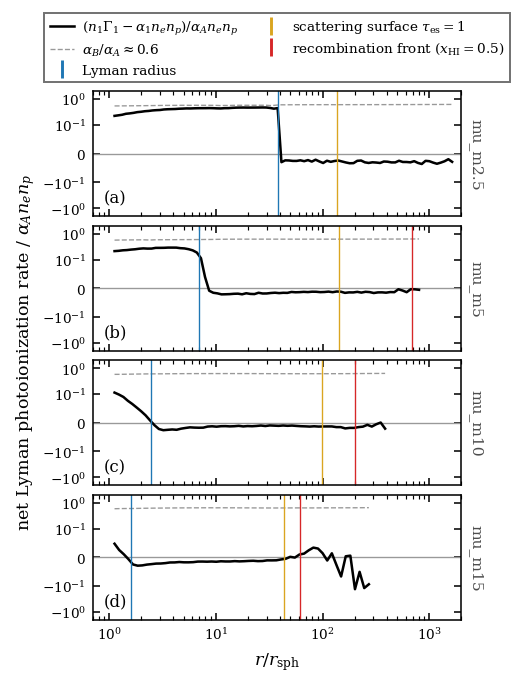

In [2]:
# ---- net ground-state photoionization (n1 Gamma_Ly - alpha_1 n_e n_p) / (alpha_A n_e n_p) vs radius, one panel per run (mu only) ----
# Sirocco's `converge` counts how many of the 3 tests (t_e, t_r, heating/cooling) a cell failed
# (0 = all pass). Blank only cells failing MORE than CONV_MAX tests. R_OUT caps the outer radius
# per run (key = Mdot label); no cap is applied to the current mu grid. Legend = two-column framed box above (a).
CONV_MAX = 2
R_OUT = {}
fig, axes = plt.subplots(len(RUNS), 1, figsize=(3.4, 4.9), sharex=True, gridspec_kw=dict(hspace=0.08))
letters = iter('abcd')
for ax, (lab, key, Mdot) in zip(axes, RUNS):
    r, ne, conv, n1, G1sim, Te, npr, rLy, h1 = load_run(run_path(key))
    G1d   = gamma1_recomb(Te, ne, npr, n1)
    rE    = R_EDD(Mdot); x = r/rE
    ok    = np.where(conv <= CONV_MAX)[0]
    sel   = ok[ok < np.searchsorted(r, R_OUT.get(lab, 1.2e18))]
    rmax  = r[sel[-1]] if len(sel) else r[0]
    msk   = r <= rmax
    cmask = lambda a: np.where(conv[msk] <= CONV_MAX, a[msk], np.nan)
    rPh   = photosphere_radius(r, ne, rmax)
    rFr   = front_radius(r[msk], h1[msk])            # recombination front x_HI=0.5, converged domain only
    rec   = ne*npr
    resid = (n1*G1sim - a1(Te)*rec)/(aA(Te)*rec)     # net ground-state photoionization in units of the total recombination rate
    caseB = aB(Te)/aA(Te)                            # Case B: n1 Gamma_Ly = alpha_A n_e n_p  ->  alpha_B/alpha_A at the cell's T_e
    ax.axhline(0.0, color='0.6', lw=0.7)
    ax.plot(x[msk], cmask(resid), color='k', lw=1.3, label=r'$(n_1\Gamma_1-\alpha_1 n_en_p)/\alpha_A n_en_p$')
    ax.plot(x[msk], cmask(caseB), color='0.6', lw=0.7, ls='--', label=r'$\alpha_B/\alpha_A\approx0.6$')
    if np.isfinite(rLy): ax.axvline(rLy/rE, color=C_LYB,  lw=0.7)
    if np.isfinite(rPh): ax.axvline(rPh/rE, color=C_PHOT, lw=0.7)
    if np.isfinite(rFr): ax.axvline(rFr/rE, color=C_FRONT, lw=0.7)
    ax.set_xscale('log'); ax.set_yscale('symlog', linthresh=0.1); ax.set_ylim(-2, 2)                 # linear; same range in all three residual figures
    ax.tick_params(which='both', labelsize=7)
    ax.text(0.03, 0.08, f'({next(letters)})', transform=ax.transAxes, ha='left', va='bottom', fontsize=8.5)
    ax.text(1.02, 0.5, f'mu_m{lab}', transform=ax.transAxes, rotation=270, ha='left', va='center', fontsize=8, color='0.30')   # right-side run label
    ib = int(np.searchsorted(r, rLy)) if np.isfinite(rLy) else 0
    beyond = (np.arange(len(r)) >= ib+2) & msk & (conv <= CONV_MAX)   # skip the transition cell itself
    q = resid[beyond]
    print(f"mu_m{lab:<4s} beyond Lyman transition: median {np.nanmedian(q):+.3f}, range {np.nanmin(q):+.3f} to {np.nanmax(q):+.3f}"
          f";  r_trans/r_sph={rLy/rE:.1f}, tau_es=1 at r/r_sph={rPh/rE:.0f}, x_HI=0.5 at r/r_sph={rFr/rE:.0f}")
h, l = axes[0].get_legend_handles_labels()
axes[0].legend(h+[vbar(C_LYB), vbar(C_PHOT), vbar(C_FRONT)], l+['Lyman radius', r'scattering surface $\tau_{\rm es}=1$', r'recombination front ($x_{\rm HI}{=}0.5$)'],
               ncol=2, loc='lower center', bbox_to_anchor=(0.5, 1.02), frameon=True, fancybox=False, edgecolor='0.3',
               fontsize=7, handlelength=1.8, handletextpad=0.6, columnspacing=1.5, labelspacing=0.4)   # framed box above panel (a)
axes[-1].set_xlabel(r'$r/r_{\rm sph}$', fontsize=9)
fig.supylabel(r'net Lyman photoionization rate / $\alpha_A n_en_p$', fontsize=9, x=-0.04)   # one shared y-label for the four panels
axes[0].set_xlim(0.7, 2e3)   # same x-range as FigGamma2/3_residuals (shows the m10 front at 200 r_sph)
fig.savefig(os.path.join(FIG_DIR, 'FigGamma1_residuals.pdf'))
fig.savefig(os.path.join(FIG_DIR, 'FigGamma1_residuals.png'), dpi=300)
plt.show()
